# **Roboflow Dataset Link** - 'https://universe.roboflow.com/intel-unnati-training-program/pothole-detection-bqu6s/dataset/7'

# **Install Dependencies**

In [1]:
!pip install -q ultralytics roboflow

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 MB 37.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 207.9/207.9 kB 15.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 66.8/66.8 kB 5.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 49.9/49.9 MB 18.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.5/1.5 MB 86.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.5/5.5 MB 143.1 MB/s eta 0:00:00


# **Import Modules**

In [2]:
import os
import random
import cv2
import matplotlib.pyplot as plt
import pandas as pd
from ultralytics import YOLO
from roboflow import Roboflow

Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.


# **Load The Dataset**

In [3]:
from roboflow import Roboflow
rf = Roboflow(api_key="5tiVmFnSNXE8lmBhSdK1")
project = rf.workspace("intel-unnati-training-program").project("pothole-detection-bqu6s")
version = project.version(7)
dataset = version.download("yolov8")

loading Roboflow workspace...
loading Roboflow project...



Extracting Dataset Version Zip to Pothole-Detection--7 in yolov8:: 100%|██████████| 7638/7638 [00:01<00:00, 5709.85it/s]


# **Data Preprocessing**

In [4]:
old_name = 'Pothole-Detection--7'
new_name = 'Pothole-Detection'

# Rename the directory
os.rename(old_name, new_name)

print(dataset.location)

/content/Pothole-Detection--7


In [5]:
# New rename location

dataset.location = '/content/Pothole-Detection'

In [6]:
import yaml

# Fix / Overwrite data.yaml File (For YOLOv8)

FIXED_YAML_PATH = f"{dataset.location}/data_fixed.yaml"

data = {
    'path': dataset.location,
    'train': 'train/images',
    'val': 'valid/images',
    'test': 'test/images',
    'nc': 3,
    'names': ['Drain Hole', 'Pothole', 'Sewer Cover']
}

with open(FIXED_YAML_PATH, 'w') as f:
    yaml.dump(data, f)

print('\n data.yaml created at:', FIXED_YAML_PATH)


 data.yaml created at: /content/Pothole-Detection/data_fixed.yaml


In [7]:
import glob

for split in ['train', 'valid', 'test']:
    img_count = len(glob.glob(os.path.join(dataset.location, split, 'images', '*.*')))
    lbl_count = len(glob.glob(os.path.join(dataset.location, split, 'labels', '*.txt')))
    print(f"{split.upper()} -> Images: {img_count} | Labels: {lbl_count}")

TRAIN -> Images: 3076 | Labels: 3076
VALID -> Images: 491 | Labels: 491
TEST -> Images: 246 | Labels: 246


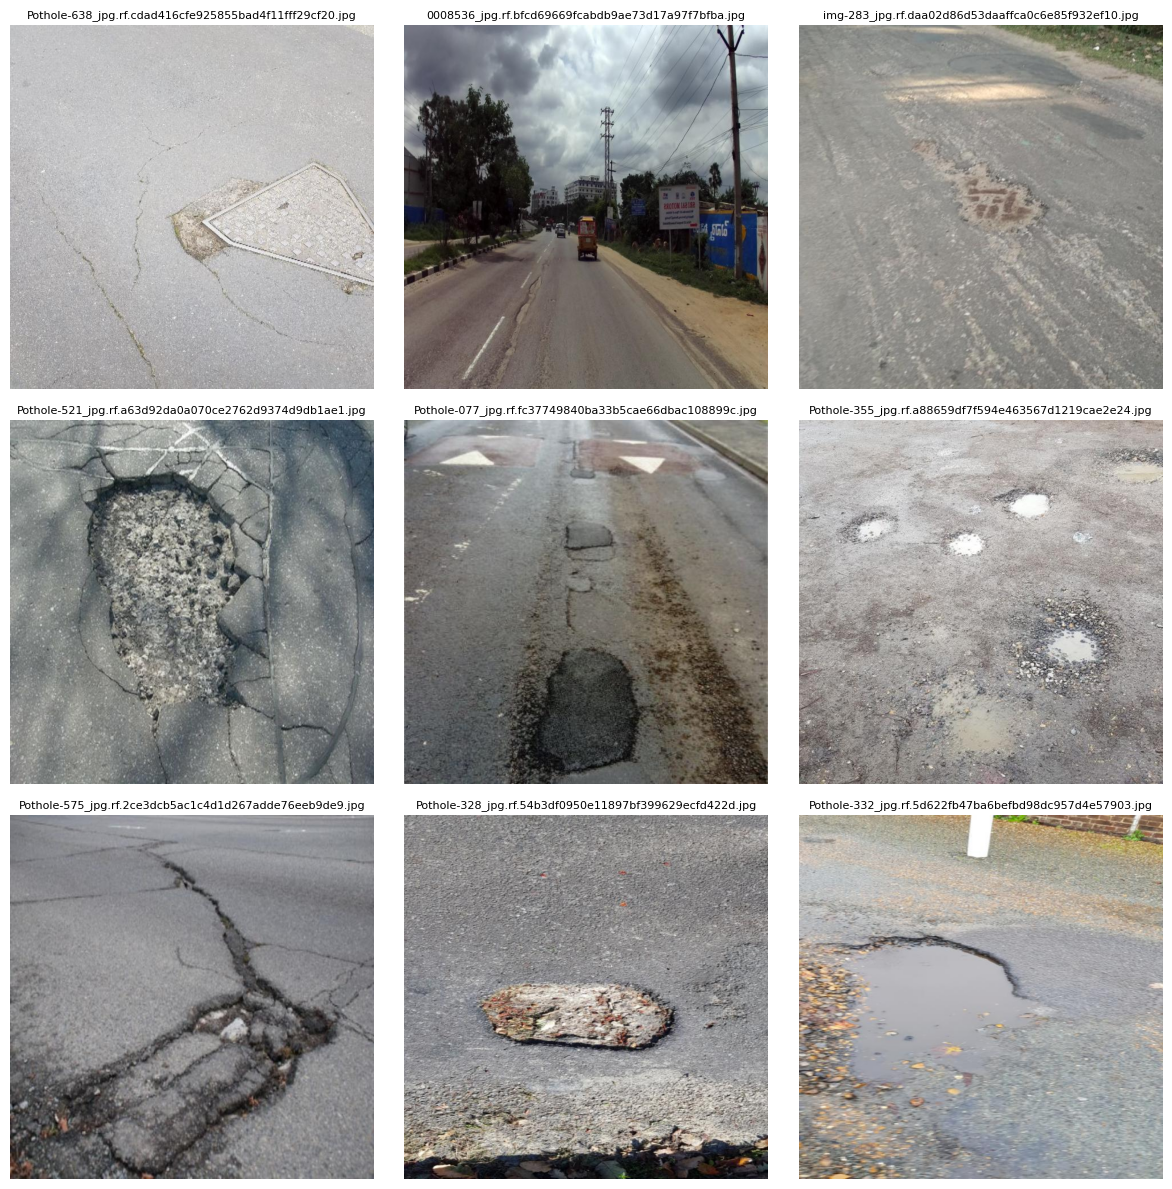

In [8]:
# Visualize Random Train Images (Before Training)

TRAIN_IMG_DIR = f'{dataset.location}/train/images'

train_images = os.listdir(TRAIN_IMG_DIR)
sample_images = random.sample(train_images, 9)

plt.figure(figsize=(12, 12))

for i, image_name in enumerate(sample_images):
  image_path = os.path.join(TRAIN_IMG_DIR, image_name)

  img = cv2.imread(image_path)
  img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

  plt.subplot(3, 3, i+1)
  plt.imshow(img)
  plt.title(image_name, fontsize = 8)
  plt.axis('off')

plt.tight_layout()
plt.show()

# **Model Building**

In [9]:
# Load The YOLO Model

model = YOLO('yolov8n.pt')

In [10]:
# Train The YOLO Model

model.train(
    data = FIXED_YAML_PATH,
    epochs = 50,
    batch = 16,
    imgsz = 640,
    name = 'train',
    cache = True,
    exist_ok = True
)

Ultralytics 8.4.51 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=True, cfg=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/Pothole-Detection/data_fixed.yaml, degrees=0.0, deterministic=True, device=None, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=50, erasing=0.4, exist_ok=True, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolov8n.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=train, nbs=64, nms=False, opset=None, optimize=False, optimizer=auto, overlap_mask=True, pa

ultralytics.utils.metrics.DetMetrics object with attributes:

ap_class_index: array([0, 1, 2])
box: ultralytics.utils.metrics.Metric object
confusion_matrix: <ultralytics.utils.metrics.ConfusionMatrix object at 0x7fa3f82ebfe0>
curves: ['Precision-Recall(B)', 'F1-Confidence(B)', 'Precision-Confidence(B)', 'Recall-Confidence(B)']
curves_results: [[array([          0,    0.001001,    0.002002,    0.003003,    0.004004,    0.005005,    0.006006,    0.007007,    0.008008,    0.009009,     0.01001,    0.011011,    0.012012,    0.013013,    0.014014,    0.015015,    0.016016,    0.017017,    0.018018,    0.019019,     0.02002,    0.021021,    0.022022,    0.023023,
          0.024024,    0.025025,    0.026026,    0.027027,    0.028028,    0.029029,     0.03003,    0.031031,    0.032032,    0.033033,    0.034034,    0.035035,    0.036036,    0.037037,    0.038038,    0.039039,     0.04004,    0.041041,    0.042042,    0.043043,    0.044044,    0.045045,    0.046046,    0.047047,
          0.04

In [11]:
# Check the results

results_csv = '/content/runs/detect/train/results.csv'
df = pd.read_csv(results_csv)

df.head()

,epoch,time,train/box_loss,train/cls_loss,train/dfl_loss,metrics/precision(B),metrics/recall(B),metrics/mAP50(B),metrics/mAP50-95(B),val/box_loss,val/cls_loss,val/dfl_loss,lr/pg0,lr/pg1,lr/pg2
0,1,57.2716,1.54123,2.44944,1.56164,0.55454,0.53753,0.46349,0.22494,1.62065,2.33980,1.73570,0.000474,0.000474,0.000474
1,2,108.9760,1.49842,1.86953,1.50949,0.37630,0.53368,0.33297,0.14164,1.66533,2.31340,1.69179,0.000931,0.000931,0.000931
2,3,161.3520,1.52263,1.72701,1.54351,0.58168,0.51367,0.56701,0.27962,1.62773,1.76508,1.69320,0.001370,0.001370,0.001370
3,4,214.3750,1.51739,1.61334,1.54074,0.61864,0.56032,0.56190,0.25003,1.61535,1.99577,1.65788,0.001344,0.001344,0.001344
4,5,266.8090,1.45305,1.51431,1.49881,0.79755,0.67375,0.72383,0.37894,1.60232,1.65566,1.63759,0.001316,0.001316,0.001316


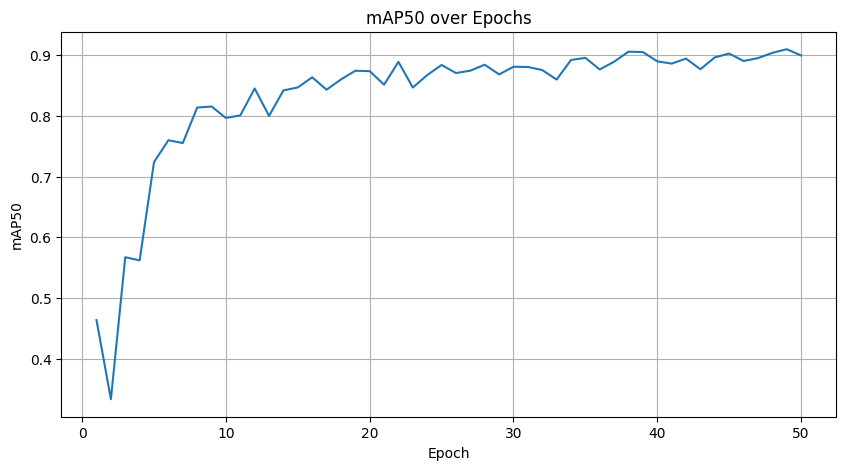

In [12]:
# PLOT TRAINING GRAPH (mAP50 over Epochs)

plt.figure(figsize=(10, 5))
plt.plot(df["epoch"], df["metrics/mAP50(B)"])
plt.title("mAP50 over Epochs")
plt.xlabel("Epoch")
plt.ylabel("mAP50")
plt.grid(True)
plt.show()

# **Model Evaluation**

In [13]:
# LOAD BEST MODEL

BEST_MODEL_PATH = '/content/runs/detect/train/weights/best.pt'
best_model = YOLO(BEST_MODEL_PATH)

In [14]:
# Evaluate On Test Dataset (After Prediction)

best_model.val(
    data = FIXED_YAML_PATH,
    split = 'test'
)

Ultralytics 8.4.51 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
Model summary (fused): 73 layers, 3,006,233 parameters, 0 gradients, 8.1 GFLOPs
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 16.0±7.5 MB/s, size: 79.3 KB)
val: Scanning /content/Pothole-Detection/test/labels... 246 images, 1 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 246/246 487.8it/s 0.5s
val: New cache created: /content/Pothole-Detection/test/labels.cache
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 16/16 3.9it/s 4.1s
                   all        246        505      0.865      0.849      0.867      0.536
            Drain Hole          9          9      0.882      0.832      0.836       0.43
               Pothole        222        473      0.854      0.802      0.853      0.622
           Sewer Cover         17         23      0.859      0.913      0.912      0.556
Speed: 2.9ms preprocess, 4.2ms inference, 0.0ms loss, 1.7ms postproces

ultralytics.utils.metrics.DetMetrics object with attributes:

ap_class_index: array([0, 1, 2])
box: ultralytics.utils.metrics.Metric object
confusion_matrix: <ultralytics.utils.metrics.ConfusionMatrix object at 0x7fa2c6cb6240>
curves: ['Precision-Recall(B)', 'F1-Confidence(B)', 'Precision-Confidence(B)', 'Recall-Confidence(B)']
curves_results: [[array([          0,    0.001001,    0.002002,    0.003003,    0.004004,    0.005005,    0.006006,    0.007007,    0.008008,    0.009009,     0.01001,    0.011011,    0.012012,    0.013013,    0.014014,    0.015015,    0.016016,    0.017017,    0.018018,    0.019019,     0.02002,    0.021021,    0.022022,    0.023023,
          0.024024,    0.025025,    0.026026,    0.027027,    0.028028,    0.029029,     0.03003,    0.031031,    0.032032,    0.033033,    0.034034,    0.035035,    0.036036,    0.037037,    0.038038,    0.039039,     0.04004,    0.041041,    0.042042,    0.043043,    0.044044,    0.045045,    0.046046,    0.047047,
          0.04

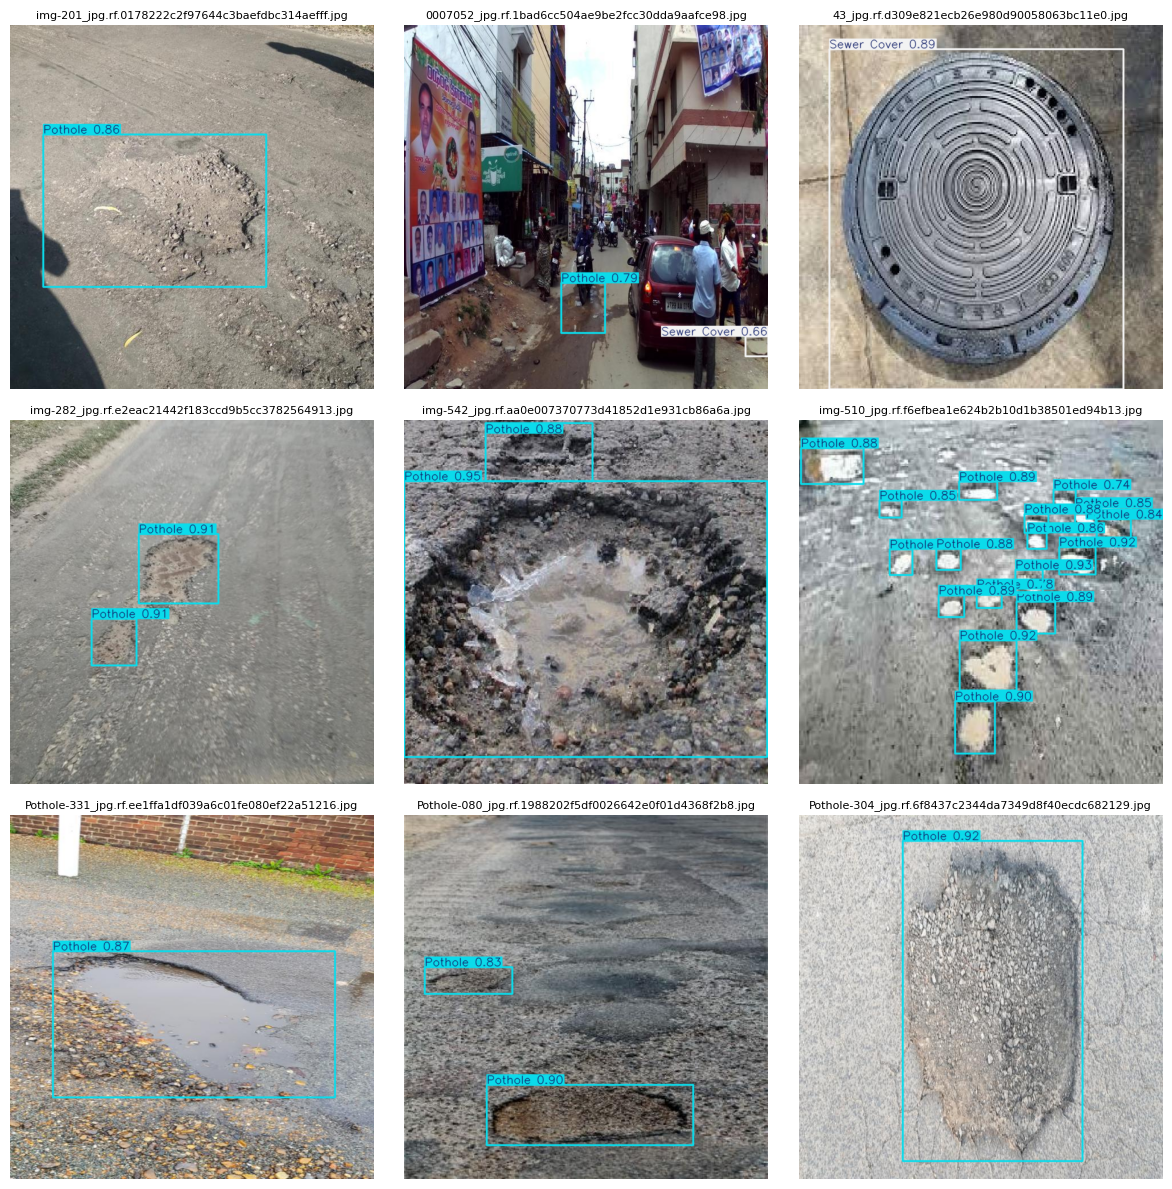

In [15]:
# VISUALIZE RANDOM TEST PREDICTIONS (AFTER TRAINING) - > Plot using yolo's result function

TEST_IMG_DIR = f'{dataset.location}/test/images'

test_images = os.listdir(TEST_IMG_DIR)
sample_test_images = random.sample(test_images, 9)

plt.figure(figsize=(12, 12))

for i, image_name in enumerate(sample_test_images):
  image_path = os.path.join(TEST_IMG_DIR, image_name)

  results = best_model.predict(image_path, conf=0.4, imgsz=640, verbose=False)[0]

  annotated_img = results.plot()
  #annotated_img = results.plot(conf=True, labels=False)

  annotated_img = cv2.cvtColor(annotated_img, cv2.COLOR_BGR2RGB)

  plt.subplot(3, 3, i+1)
  plt.imshow(annotated_img)
  plt.title(image_name, fontsize=8)
  plt.axis('off')

plt.tight_layout()
plt.show()

In [17]:
image_path = "/content/plot-hole.JPG"
image_name = os.path.basename(image_path)
image_name

'plot-hole.JPG'

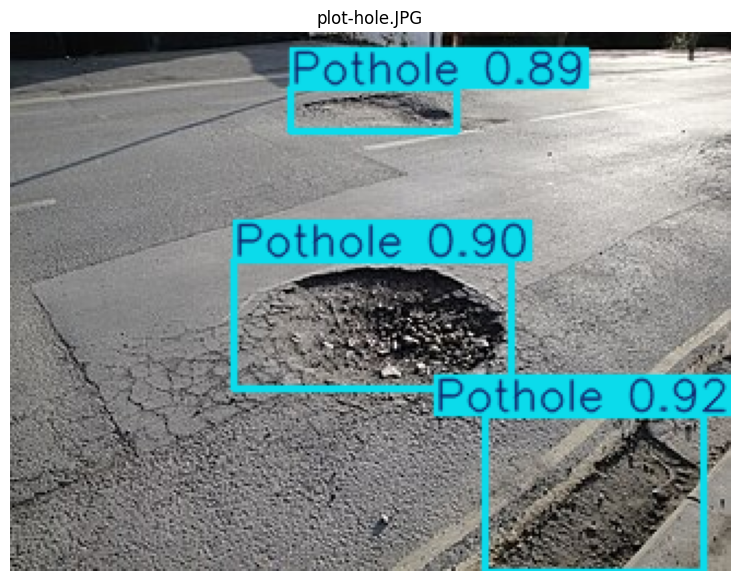

In [18]:
# Single Image

# ==============================
# SINGLE IMAGE PATH
# ==============================
#image_path = f"{dataset.location}/test/images/plot-hole.png"   # <-- change image name
image_path = "/content/plot-hole.JPG"
image_name = os.path.basename(image_path)

# ==============================
# YOLO PREDICTION
# ==============================
results = model.predict(
    image_path,
    conf=0.4,
    imgsz=640,
    verbose=False
)[0]

# ==============================
# PLOT YOLO RESULT
# ==============================
annotated_image = results.plot()

# Convert BGR to RGB for matplotlib
annotated_image = cv2.cvtColor(
    annotated_image,
    cv2.COLOR_BGR2RGB
)

# ==============================
# SHOW IMAGE
# ==============================
plt.figure(figsize=(10, 7))

plt.imshow(annotated_image)

plt.title(image_name, fontsize=12)

plt.axis("off")

plt.show()

In [19]:
# DOWNLOAD BEST MODEL (best.pt)

from google.colab import files
files.download(BEST_MODEL_PATH)

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>